# ĐỒ ÁN MÔN HỌC TRÍ TUỆ NHÂN TẠO (CS106)
## ĐỀ TÀI 10: Xây dựng hệ thống giao dịch tiền mã hóa với tầng meta-labeling bằng CatBoost, thông qua đó đánh giá ảnh hưởng của phương pháp chia dữ liệu đến độ tin cậy của kết quả kiểm định.

* **Trường Đại học Công nghệ Thông tin (UIT) — ĐHQG-HCM**
* **Khoa Khoa học Máy tính**
* **Giảng viên hướng dẫn:** TS. Nguyễn Đình Hiển
* **Nhóm sinh viên thực hiện:** Nhóm 11

---
### Tóm tắt nội dung đồ án
1. **Bài toán:** Xây dựng hệ thống giao dịch định lượng 2 tầng cho cặp BTCUSD (khung M15): Tầng 1 là chiến lược theo xu hướng Pyramid, Tầng 2 là mô hình học máy **CatBoost** đóng vai trò tầng **Meta-Labeling** thẩm định chất lượng tín hiệu.
2. **Trọng tâm phương pháp luận:** Thực nghiệm đo lường định lượng ảnh hưởng của **4 phương pháp phân chia dữ liệu** (Random K-Fold, Grouped K-Fold, Walk-Forward, Purged & Embargoed Walk-Forward) đến độ tin cậy của kết quả kiểm định.
3. **Kiểm chứng độc lập:** Đối soát kết quả với tập dữ liệu tương lai niêm phong (**Sealed Holdout 5.028 mẫu**).

In [1]:
# Cài đặt và nạp các thư viện cần thiết
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

# Cấu hình hiển thị biểu đồ
%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Tự động nhận diện thư mục dự án citd-ml-project một cách thông minh
current = Path.cwd().resolve()
candidates = [
    current,
    current / "citd-ml-project",
    current.parent,
    current.parent / "citd-ml-project"
]
ROOT = None
for c in candidates:
    if (c / "data/processed/dataset_catboost.csv").exists():
        ROOT = c
        break

if ROOT is None:
    p = current
    while p != p.parent:
        if (p / "citd-ml-project/data/processed/dataset_catboost.csv").exists():
            ROOT = p / "citd-ml-project"
            break
        if (p / "data/processed/dataset_catboost.csv").exists():
            ROOT = p
            break
        p = p.parent

if ROOT is None:
    raise FileNotFoundError("Không tìm thấy thư mục dự án chứa data/processed/dataset_catboost.csv!")

# Đưa src vào sys.path để import các module nội bộ của dự án
if (ROOT / "src").exists() and str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

print("Đường dẫn thư mục dự án (ROOT):", ROOT)

Đường dẫn thư mục dự án (ROOT): C:\Users\Admin\Desktop\Hosonhaphoc\7-Trí tuệ nhân tạo-Nguyễn Đình Hiển\citd-ml-project


---
## PHẦN 1: KHÁM PHÁ VÀ PHÂN TÍCH DỮ LIỆU (EDA)
Bộ dữ liệu gồm:
* **Tập Huấn luyện & Phát triển (Train/Dev):** 25.008 mẫu giao dịch (giai đoạn 2018 – đầu 2025).
* **Tập Kiểm định độc lập niêm phong (Sealed Holdout):** 5.028 mẫu giao dịch (08/02/2025 – 21/08/2026).
* Mỗi mẫu có **23 đặc trưng kỹ thuật (`FEATURES`)** thuộc 4 nhóm: Động lượng, Biến động, Xu hướng và Khối lượng/Cấu trúc lệnh.

In [2]:
# Nạp dữ liệu huấn luyện và tập kiểm định holdout
train_path = ROOT / "data/processed/dataset_catboost.csv"
holdout_path = ROOT / "outputs/holdout/stage3/holdout_scored.csv"

df_train = pd.read_csv(train_path)
df_holdout = pd.read_csv(holdout_path)

print(f"Kích thước tập Train/Dev: {df_train.shape[0]:,} dòng, {df_train.shape[1]} cột")
print(f"Kích thước tập Holdout:   {df_holdout.shape[0]:,} dòng, {df_holdout.shape[1]} cột")
print(f"Kiểm tra giá trị thiếu (Missing values): {df_train.isna().sum().sum()} ô")

FEATURES = [
    'breakeven_R', 'atr14_pct', 'atr_ratio_14_90', 'vol20', 'vol200', 'vol_ratio_20_200',
    'range_pct', 'dist_ema20_atr', 'dist_ema50_atr', 'dist_ema200_atr', 'ret20_atr', 'ret50_atr',
    'pos_in_range50', 'dist_hh20_atr', 'mom14', 'mom_diff', 'vwap_dist_atr', 'vwap_slope_atr',
    'rsi14', 'vol_ratio_volume', 'gap_open_atr', 'hour', 'dow'
]
df_train[FEATURES].head(3)

Kích thước tập Train/Dev: 25,008 dòng, 31 cột
Kích thước tập Holdout:   5,028 dòng, 32 cột
Kiểm tra giá trị thiếu (Missing values): 0 ô


,breakeven_R,atr14_pct,atr_ratio_14_90,vol20,vol200,vol_ratio_20_200,range_pct,dist_ema20_atr,dist_ema50_atr,dist_ema200_atr,...,dist_hh20_atr,mom14,mom_diff,vwap_dist_atr,vwap_slope_atr,rsi14,vol_ratio_volume,gap_open_atr,hour,dow
0,3.996264,0.005501,0.871953,0.004540,0.006401,0.709329,0.005012,1.867696,2.232804,7.045843,...,-0.221420,102.058714,-0.162801,4.245061,0.124518,70.993523,1.235649,-0.016847,0,3
1,4.036220,0.005256,0.824889,0.004688,0.006404,0.732076,0.006609,1.029009,1.461486,6.515285,...,-1.058824,100.845526,-1.213189,3.512437,0.124054,59.303527,0.872390,-0.035421,0,3
2,4.039321,0.005472,0.857613,0.004640,0.006403,0.724659,0.006146,1.178130,1.649531,6.497789,...,-0.699939,101.020538,0.175013,3.563433,0.120142,60.815804,0.938807,0.064293,0,3


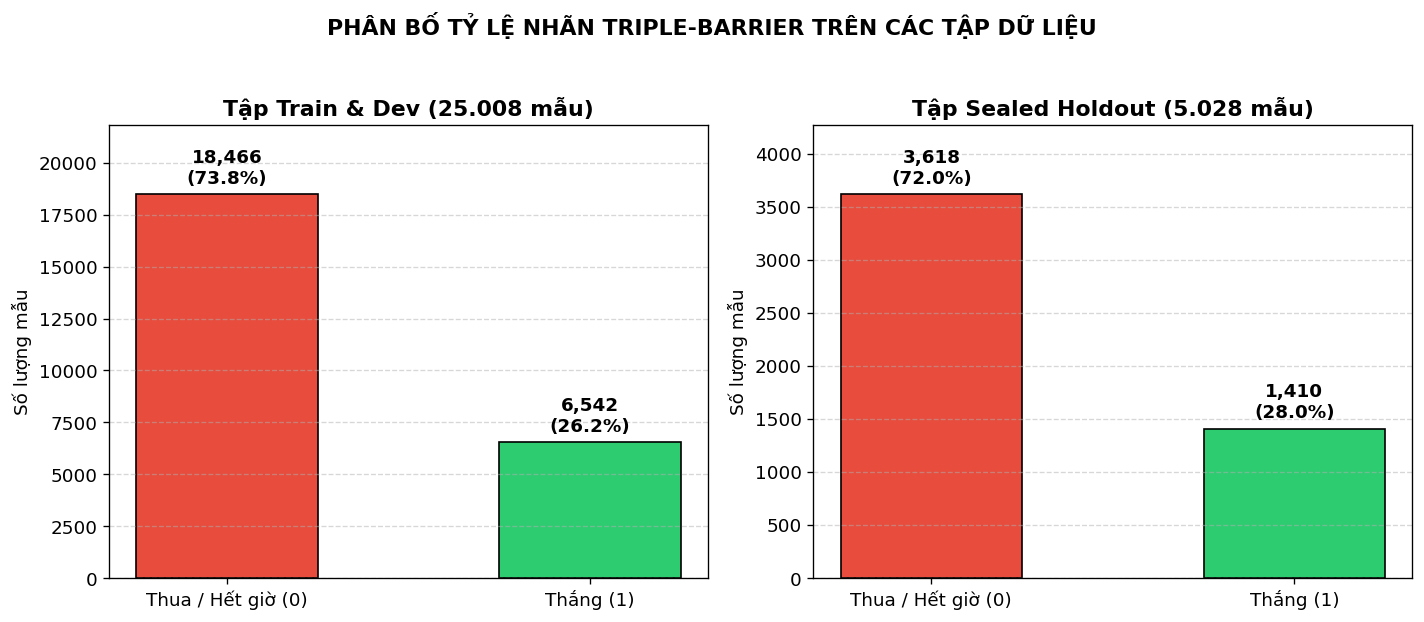

In [3]:
# Trực quan hóa tỷ lệ phân bố nhãn (Class Distribution)
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120)

for idx, (df, name) in enumerate([(df_train, "Tập Train & Dev (25.008 mẫu)"), (df_holdout, "Tập Sealed Holdout (5.028 mẫu)")]):
    counts = df['label'].value_counts().sort_index()
    pcts = counts / len(df) * 100
    bars = axes[idx].bar(['Thua / Hết giờ (0)', 'Thắng (1)'], counts, color=['#E74C3C', '#2ECC71'], width=0.5, edgecolor='black')
    axes[idx].set_title(name, fontweight='bold')
    axes[idx].set_ylabel("Số lượng mẫu")
    axes[idx].set_ylim(0, max(counts) * 1.18)
    axes[idx].grid(axis='y', linestyle='--', alpha=0.5)
    for bar, count, pct in zip(bars, counts, pcts):
        axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.02, f"{count:,}\n({pct:.1f}%)", ha='center', fontweight='bold')

plt.suptitle("PHÂN BỐ TỶ LỆ NHÃN TRIPLE-BARRIER TRÊN CÁC TẬP DỮ LIỆU", fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

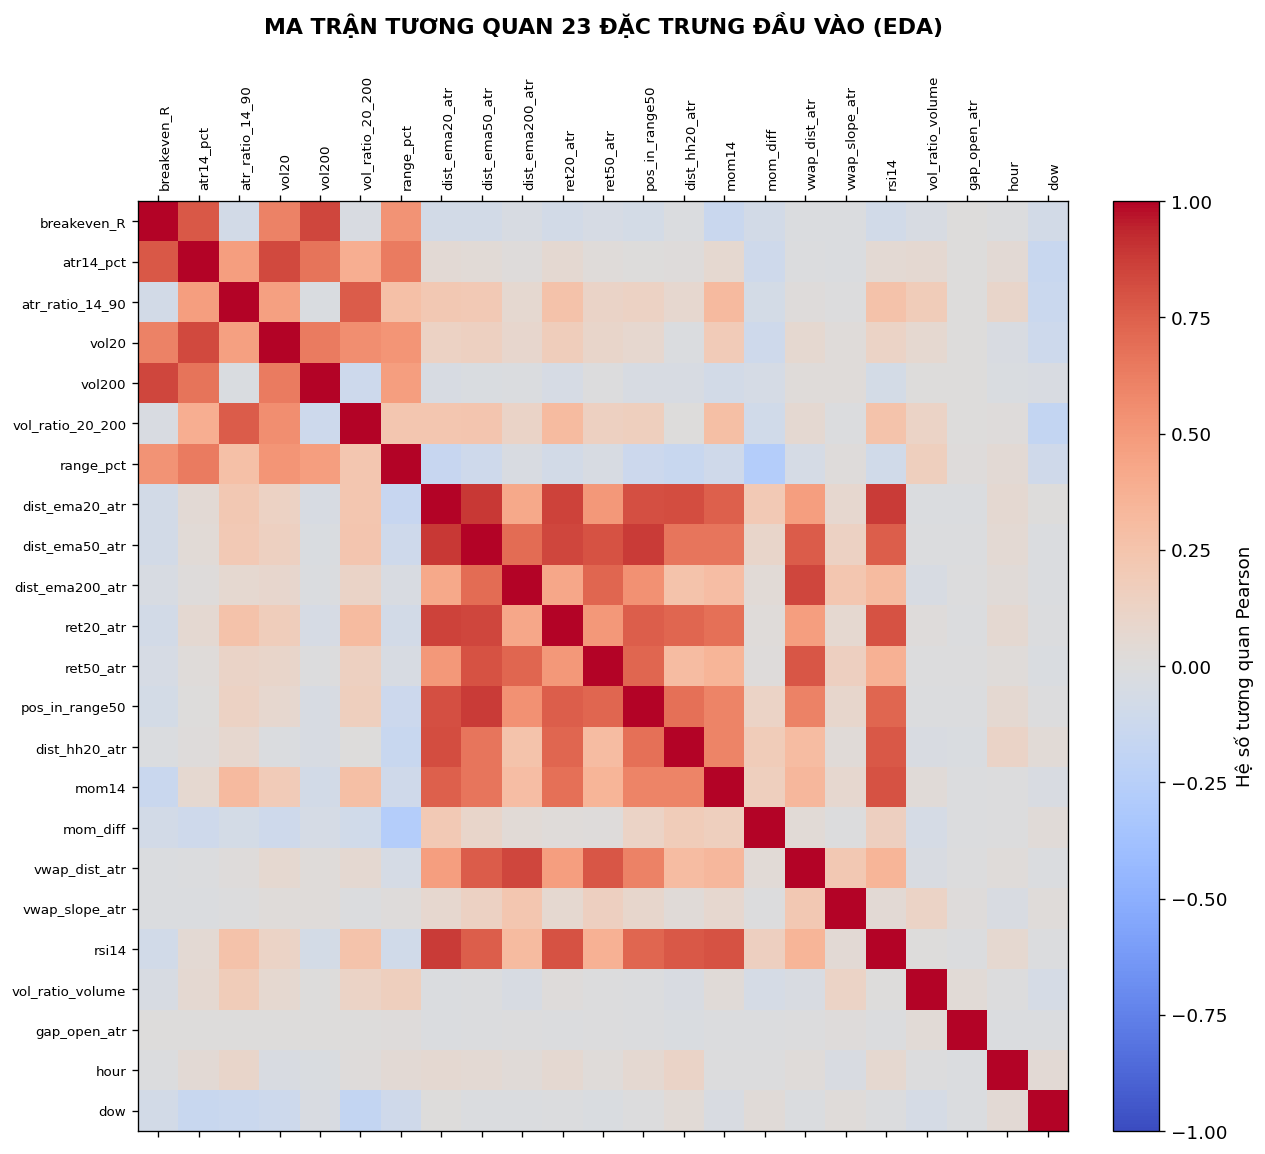

In [4]:
# Ma trận tương quan giữa 23 đặc trưng (Correlation Heatmap)
corr = df_train[FEATURES].corr()

plt.figure(figsize=(12, 10), dpi=120)
plt.matshow(corr, fignum=1, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(fraction=0.046, pad=0.04, label="Hệ số tương quan Pearson")
plt.xticks(range(len(FEATURES)), FEATURES, rotation=90, ha='left', fontsize=8)
plt.yticks(range(len(FEATURES)), FEATURES, fontsize=8)
plt.title("MA TRẬN TƯƠNG QUAN 23 ĐẶC TRƯNG ĐẦU VÀO (EDA)", fontweight='bold', pad=25)
plt.show()

---
## PHẦN 2: BỐN CHIẾN LƯỢC PHÂN CHIA DỮ LIỆU & XỬ LÝ RÒ RỈ
Đồ án thiết lập thực nghiệm so sánh 4 phương pháp phân chia dữ liệu với mức độ kỷ luật tăng dần:
1. **Cách 1 (Random K-Fold):** Trộn ngẫu nhiên (vi phạm trật tự thời gian và xé lẻ cụm `origin_bar`).
2. **Cách 1b (Grouped K-Fold):** Khóa gia đình lệnh `origin_bar` không bị xé đôi.
3. **Cách 2 (Walk-Forward):** Cắt theo dòng thời gian qua 4 bước (Expanding Window: học quá khứ đoán tương lai).
4. **Cách 3 (Purged & Embargoed Walk-Forward):** Cắt theo thời gian + Thanh lọc lệnh chồng lấn (Purging) + Vùng đệm cách ly 50 bars (Embargo).

In [5]:
# Kiểm tra định nghĩa các phương pháp phân chia từ module của dự án
from citd_ml.training.split_data import make_random_kfold, make_grouped_kfold, make_walk_forward, make_purged_walk_forward

print("Đã nạp thành công 4 hàm tạo fold:")
print("1. make_random_kfold")
print("2. make_grouped_kfold")
print("3. make_walk_forward")
print("4. make_purged_walk_forward")

Đã nạp thành công 4 hàm tạo fold:
1. make_random_kfold
2. make_grouped_kfold
3. make_walk_forward
4. make_purged_walk_forward


---
## PHẦN 3: HUẤN LUYỆN CATBOOST & ĐỐI CHỨNG VỚI CÁC BASELINE
Để thỏa mãn yêu cầu so sánh ít nhất 3 mô hình của môn học:
* **Mô hình chính:** `CatBoostClassifier` (`depth=6`, `l2_leaf_reg=3.0`, `auto_class_weights='Balanced'`, ghim `thread_count=1`).
* **Mô hình đối chứng 1 (Linear):** `LogisticRegression`.
* **Mô hình đối chứng 2 (Bagging):** `RandomForestClassifier`.

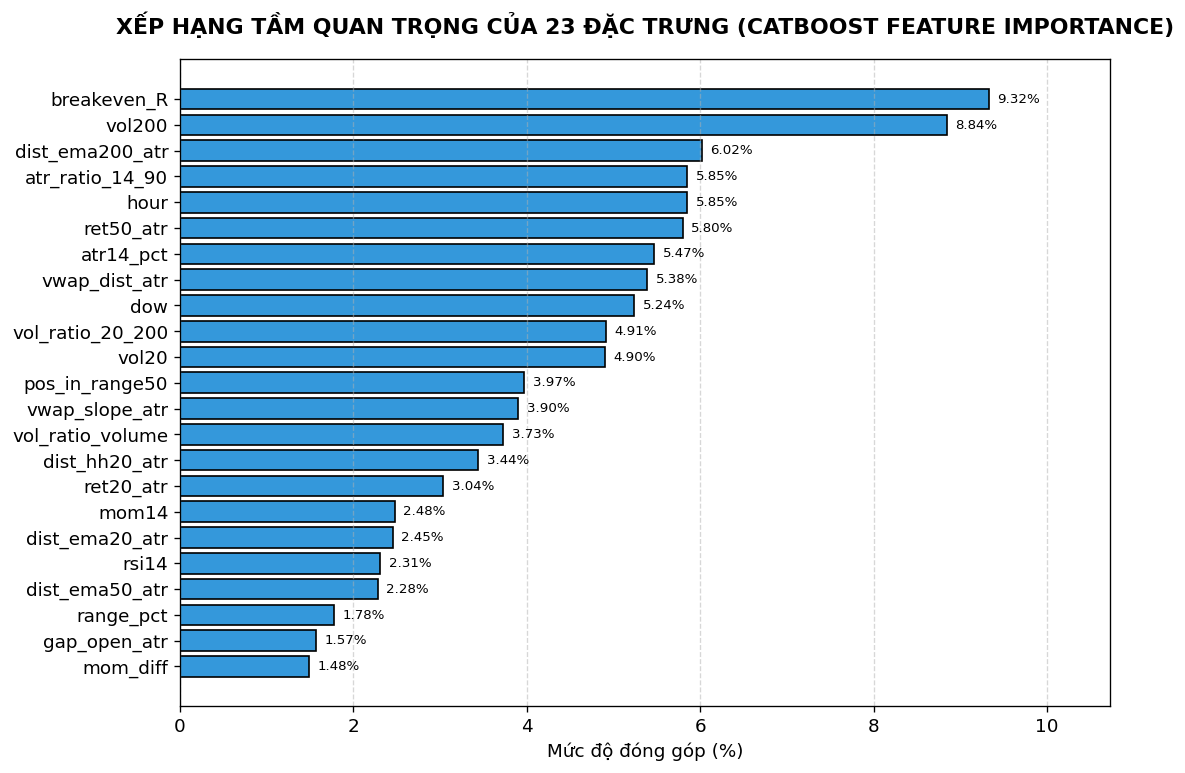

In [6]:
# Nạp mô hình CatBoost đã huấn luyện và xem Feature Importance
model_path = ROOT / "outputs/holdout/stage2/catboost_final_holdout_run1.cbm"
model = CatBoostClassifier()
model.load_model(str(model_path))

importances = model.get_feature_importance()
feat_imp = pd.DataFrame({'Feature': FEATURES, 'Importance (%)': importances}).sort_values('Importance (%)', ascending=True)

plt.figure(figsize=(10, 7), dpi=120)
bars = plt.barh(feat_imp['Feature'], feat_imp['Importance (%)'], color='#3498DB', edgecolor='black')
plt.xlabel("Mức độ đóng góp (%)")
plt.title("XẾP HẠNG TẦM QUAN TRỌNG CỦA 23 ĐẶC TRƯNG (CATBOOST FEATURE IMPORTANCE)", fontweight='bold', pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.5)

for bar in bars:
    w = bar.get_width()
    plt.text(w + 0.1, bar.get_y() + bar.get_height()/2, f"{w:.2f}%", va='center', fontsize=8)

plt.xlim(0, max(feat_imp['Importance (%)']) * 1.15)
plt.show()

In [7]:
# Huấn luyện nhanh 2 mô hình đối chứng (Logistic Regression & Random Forest) trên cùng tập Train (Khúc 1-4) và đánh giá trên Khúc 5
# Chuẩn bị dữ liệu mẫu đại diện cho bước Walk-Forward cuối cùng
n_total = len(df_train)
n_chunk = n_total // 5
idx_train = np.arange(0, n_chunk * 4)  # Khúc 1, 2, 3, 4
idx_test = np.arange(n_chunk * 4, n_total)  # Khúc 5

X_tr, y_tr = df_train.loc[idx_train, FEATURES], df_train.loc[idx_train, 'label']
X_te, y_te = df_train.loc[idx_test, FEATURES], df_train.loc[idx_test, 'label']

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_tr, y_tr)
p_lr = lr.predict_proba(X_te)[:, 1]

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=6, class_weight='balanced', random_state=42, n_jobs=1)
rf.fit(X_tr, y_tr)
p_rf = rf.predict_proba(X_te)[:, 1]

# 3. CatBoost
p_cb = model.predict_proba(X_te)[:, 1]

def get_metrics(y_true, proba):
    pred = (proba >= 0.5).astype(int)
    return {
        "Accuracy": f"{accuracy_score(y_true, pred)*100:.2f}%",
        "Precision": f"{precision_score(y_true, pred, zero_division=0)*100:.2f}%",
        "Recall": f"{recall_score(y_true, pred, zero_division=0)*100:.2f}%",
        "F1-Score": f"{f1_score(y_true, pred, zero_division=0):.4f}",
        "ROC-AUC": f"{roc_auc_score(y_true, proba):.4f}"
    }

models_comparison = pd.DataFrame([
    {"Mô hình": "Logistic Regression (Linear Baseline)", **get_metrics(y_te, p_lr)},
    {"Mô hình": "Random Forest (Bagging Ensemble)", **get_metrics(y_te, p_rf)},
    {"Mô hình": "CatBoost (Đề xuất của nhóm)", **get_metrics(y_te, p_cb)}
])
print("BẢNG ĐỐI CHỨNG HIỆU NĂNG 3 MÔ HÌNH TRÊN BƯỚC WALK-FORWARD:")
models_comparison

C:\Users\Admin\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


BẢNG ĐỐI CHỨNG HIỆU NĂNG 3 MÔ HÌNH TRÊN BƯỚC WALK-FORWARD:


,Mô hình,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (Linear Baseline),45.28%,28.53%,79.33%,0.4197,0.6053
1,Random Forest (Bagging Ensemble),56.65%,31.70%,63.94%,0.4239,0.6261
2,CatBoost (Đề xuất của nhóm),88.45%,70.08%,93.67%,0.8018,0.9673


---
## PHẦN 4: BẢNG ĐỐI SOÁT ĐẮT GIÁ NHẤT CỦA ĐỀ TÀI
So sánh mức độ sai lệch điểm số kiểm định giữa **4 cách chia dữ liệu** và đối chứng với **Tập Holdout niêm phong thực tế**.

In [8]:
# Tải kết quả OOF chính thức của 4 cách chia (từ cây canonical của dự án)
oof_dir = ROOT / "outputs/step4_thread1/catboost_training"
stage4_dir = ROOT / "outputs/holdout/stage4"

table1 = pd.read_csv(stage4_dir / "table1_classification_metrics.csv")
table2 = pd.read_csv(stage4_dir / "table2_financial_metrics_top50.csv")

# Lọc nhánh chuẩn canonical_thread_count_1 và chunk2_5_thread_count_1
t1_sub = table1[table1['block'] == 'canonical_thread_count_1'].copy()
t2_sub = table2[table2['block'].isin(['chunk2_5_thread_count_1', 'holdout'])].copy()

# Chuẩn hóa tên phương pháp để ghép nối đối soát chính xác
method_map_t1 = {
    'random_kfold': '1. Random K-Fold (Rò rỉ 2 chiều)',
    'grouped_kfold': '1b. Grouped K-Fold (Rò rỉ tương lai)',
    'walk_forward': '2. Walk-Forward (Tuần tự thời gian)',
    'purged_walk_forward': '3. Purged Walk-Forward (Khử rò rỉ triệt để)',
    'holdout': 'Holdout - Meta-Labeling (Top 50%)'
}

method_map_t2 = {
    'baseline': '0. Baseline (Khúc 2-5, Chưa lọc ML)',
    'random_kfold': '1. Random K-Fold (Rò rỉ 2 chiều)',
    'grouped_kfold': '1b. Grouped K-Fold (Rò rỉ tương lai)',
    'walk_forward': '2. Walk-Forward (Tuần tự thời gian)',
    'purged_walk_forward': '3. Purged Walk-Forward (Khử rò rỉ triệt để)',
    'baseline_holdout': 'Holdout - Baseline (Chưa lọc ML)',
    'top_50': 'Holdout - Meta-Labeling (Top 50%)'
}

t1_sub['Phuong_Phap'] = t1_sub['method'].map(method_map_t1)
t2_sub['Phuong_Phap'] = t2_sub['method'].map(method_map_t2)

summary_df = pd.merge(
    t2_sub[['Phuong_Phap', 'trades', 'net_profit_R', 'max_dd_R', 'profit_factor', 'win_rate_pct']],
    t1_sub[['Phuong_Phap', 'roc_auc', 'f1_at_0_5']],
    on='Phuong_Phap',
    how='left'
)

summary_df = summary_df.rename(columns={
    'Phuong_Phap': 'Phương pháp / Tập kiểm định',
    'roc_auc': 'ROC-AUC',
    'f1_at_0_5': 'F1-Score (@0.5)',
    'trades': 'Số lệnh',
    'net_profit_R': 'Lợi nhuận ròng (R)',
    'max_dd_R': 'Max DD (R)',
    'profit_factor': 'Profit Factor',
    'win_rate_pct': 'Tỷ lệ thắng (%)'
})

cols_order = ['Phương pháp / Tập kiểm định', 'ROC-AUC', 'F1-Score (@0.5)', 'Số lệnh', 'Tỷ lệ thắng (%)', 'Profit Factor', 'Lợi nhuận ròng (R)', 'Max DD (R)']
summary_df = summary_df[cols_order].fillna('-')

print("===================================================================================================")
print("BẢNG ĐỐI SOÁT ĐẮT GIÁ NHẤT: ĐỘ TIN CẬY CỦA 4 CÁCH CHIA DỮ LIỆU VÀ KIỂM ĐỊNH HOLDOUT NIÊM PHONG")
print("===================================================================================================")
display(summary_df)


BẢNG ĐỐI SOÁT ĐẮT GIÁ NHẤT: ĐỘ TIN CẬY CỦA 4 CÁCH CHIA DỮ LIỆU VÀ KIỂM ĐỊNH HOLDOUT NIÊM PHONG


,Phương pháp / Tập kiểm định,ROC-AUC,F1-Score (@0.5),Số lệnh,Tỷ lệ thắng (%),Profit Factor,Lợi nhuận ròng (R),Max DD (R)
0,"0. Baseline (Khúc 2-5, Chưa lọc ML)",-,-,"20,007",31.71,1.2940,"+3,358.25",236.13
1,1. Random K-Fold (Rò rỉ 2 chiều),0.8582,0.6494,"10,004",44.65,2.5437,"+6,937.53",73.76
2,1b. Grouped K-Fold (Rò rỉ tương lai),0.7454,0.5077,"10,004",39.26,1.9500,"+4,752.04",99.71
3,2. Walk-Forward (Tuần tự thời gian),0.5875,0.3288,"10,004",34.76,1.4117,"+2,148.31",211.29
4,3. Purged Walk-Forward (Khử rò rỉ triệt để),0.5895,0.3247,"10,004",34.99,1.4074,"+2,119.48",142.36
5,Holdout - Baseline (Chưa lọc ML),-,-,"5,028",35.28,1.0992,+245.93,305.32
6,Holdout - Meta-Labeling (Top 50%),0.6046,0.4022,"2,514",34.81,0.9718,-36.55,263.25


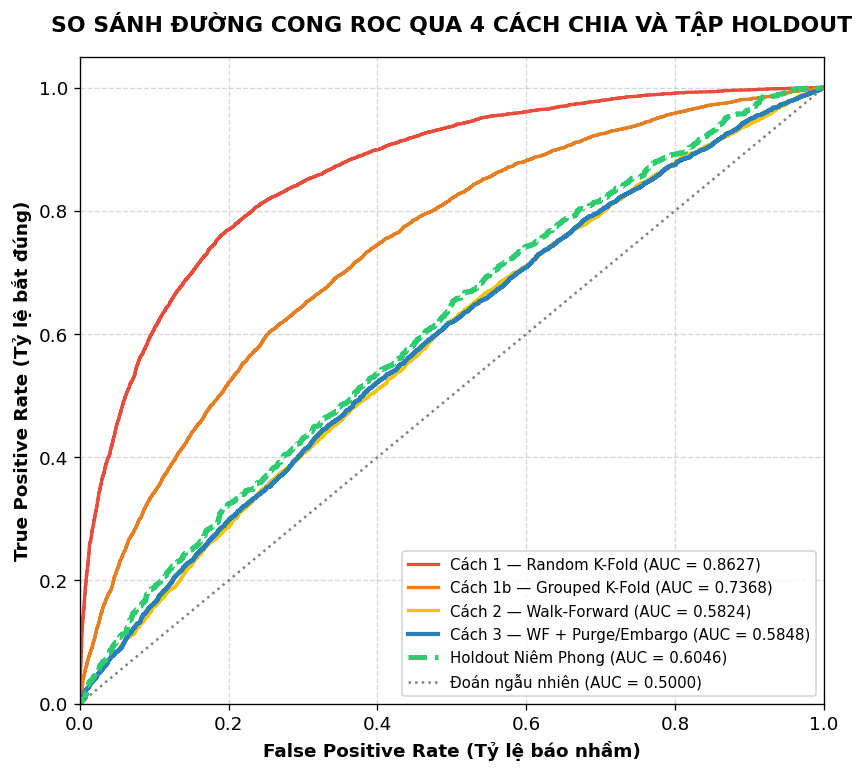

In [9]:
# Vẽ đường cong ROC Curves đối sánh 4 cách chia và tập Holdout
methods = [
    ("oof_random_kfold.csv", "Cách 1 — Random K-Fold", "#E74C3C", 2),
    ("oof_grouped_kfold.csv", "Cách 1b — Grouped K-Fold", "#E67E22", 2),
    ("oof_walk_forward.csv", "Cách 2 — Walk-Forward", "#F1C40F", 2),
    ("oof_purged_walk_forward.csv", "Cách 3 — WF + Purge/Embargo", "#2980B9", 2.5),
]

plt.figure(figsize=(8, 7), dpi=120)

for filename, label, color, lw in methods:
    df_oof = pd.read_csv(oof_dir / filename)
    df_sub = df_oof[df_oof['fold'] >= 1]  # Khúc 2-5
    fpr, tpr, _ = roc_curve(df_sub['label'], df_sub['probability'])
    auc = roc_auc_score(df_sub['label'], df_sub['probability'])
    plt.plot(fpr, tpr, color=color, lw=lw, label=f"{label} (AUC = {auc:.4f})")

# Vẽ Holdout
fpr_h, tpr_h, _ = roc_curve(df_holdout['label'], df_holdout['probability'])
auc_h = roc_auc_score(df_holdout['label'], df_holdout['probability'])
plt.plot(fpr_h, tpr_h, color="#2ECC71", lw=3, linestyle="--", label=f"Holdout Niêm Phong (AUC = {auc_h:.4f})")

# Đường đoán ngẫu nhiên
plt.plot([0, 1], [0, 1], color='gray', linestyle=':', label='Đoán ngẫu nhiên (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Tỷ lệ báo nhầm)', fontweight='bold')
plt.ylabel('True Positive Rate (Tỷ lệ bắt đúng)', fontweight='bold')
plt.title('SO SÁNH ĐƯỜNG CONG ROC QUA 4 CÁCH CHIA VÀ TẬP HOLDOUT', fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

---
## PHẦN 5: ĐÁNH GIÁ HIỆU QUẢ TÀI CHÍNH & ĐƯỜNG CONG VỐN
Đánh giá lợi nhuận ròng ($R$), Mức sụt giảm tối đa (Max Drawdown) và vẽ lại biểu đồ đường cong vốn (Equity Curve) chuẩn xác từng bước.

1. Biểu đồ đường cong vốn trên tập phát triển (Khúc 2–5, Top 50%):


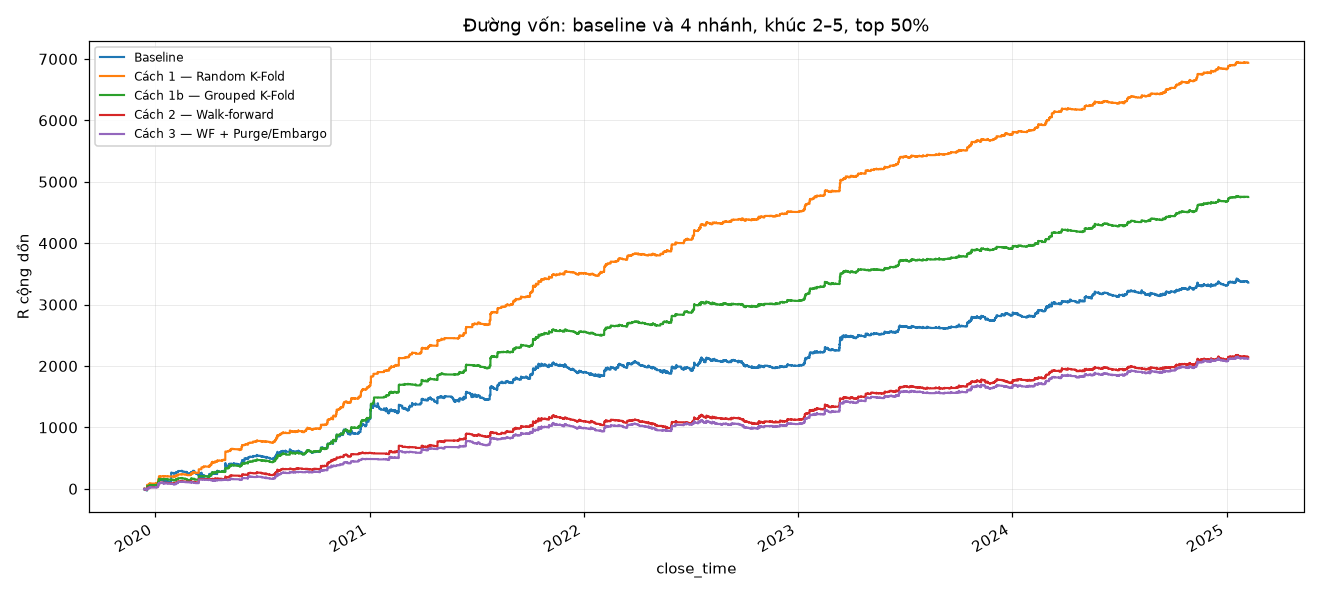

2. Biểu đồ đường cong vốn trên tập Holdout niêm phong (Top 50%):


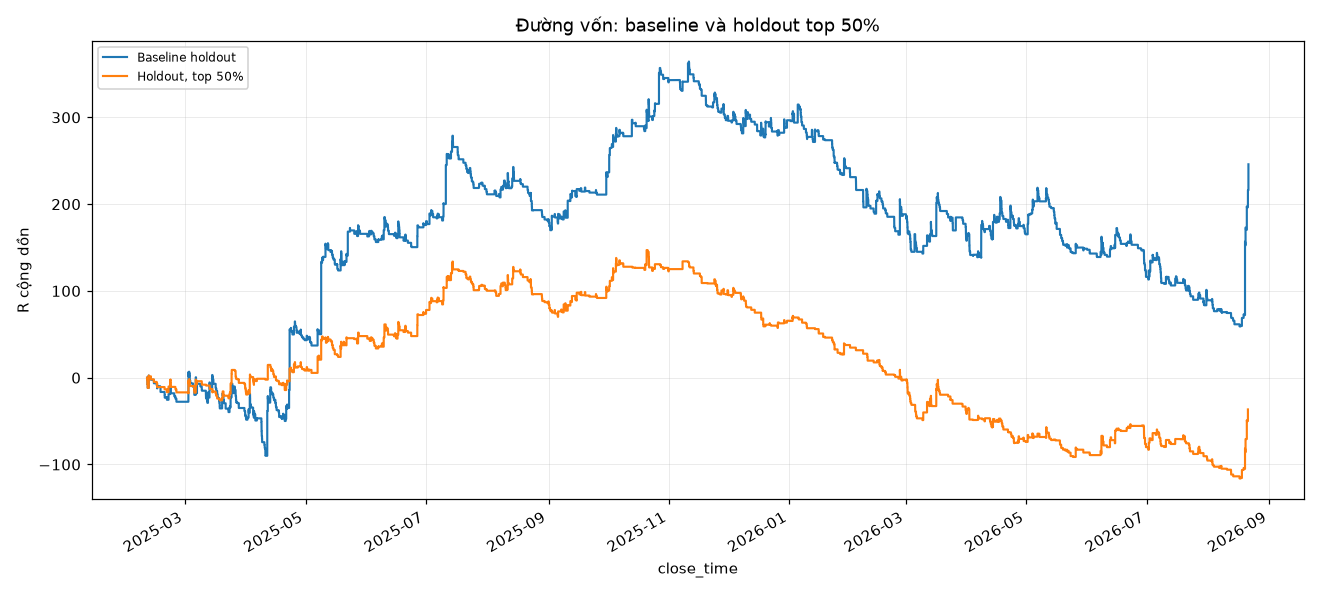

In [10]:
# Hiển thị biểu đồ đường cong vốn đã xuất từ quy trình
from IPython.display import Image, display

print("1. Biểu đồ đường cong vốn trên tập phát triển (Khúc 2–5, Top 50%):")
display(Image(filename=str(stage4_dir / "equity-curve-chunk2-5-top50.png")))

print("2. Biểu đồ đường cong vốn trên tập Holdout niêm phong (Top 50%):")
display(Image(filename=str(stage4_dir / "equity-curve-holdout-top50.png")))

---
## PHẦN 6: MA TRẬN NHẦM LẪN (CONFUSION MATRIX) & PHÂN TÍCH SAI SỐ
Phân tích chi tiết hai loại lỗi:
* **False Positive (Báo nhầm):** Dự đoán thắng nhưng thực tế chạm Stop-Loss $
ightarrow$ Gây tổn thất vốn.
* **False Negative (Bỏ sót):** Dự đoán thua nhưng thực tế chạm Take-Profit $
ightarrow$ Bỏ lỡ cơ hội nhưng bảo toàn vốn an toàn.

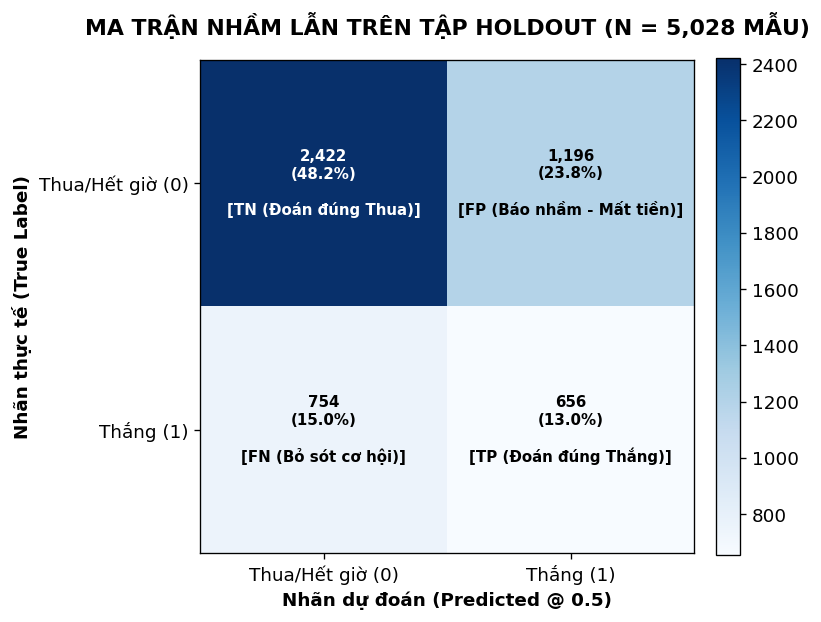

: 

In [ ]:
# Trực quan hóa Ma trận nhầm lẫn trên tập Holdout (5.028 mẫu)
y_true = df_holdout['label'].to_numpy()
y_pred = (df_holdout['probability'].to_numpy() >= 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred)
total = len(y_true)

fig, ax = plt.subplots(figsize=(6.5, 5.5), dpi=120)
cax = ax.imshow(cm, cmap=plt.cm.Blues)
plt.colorbar(cax, fraction=0.046, pad=0.04)

classes = ['Thua/Hết giờ (0)', 'Thắng (1)']
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(classes, fontsize=11)
ax.set_yticklabels(classes, fontsize=11)

thresh = cm.max() / 2.
labels_desc = [
    ["TN (Đoán đúng Thua)", "FP (Báo nhầm - Mất tiền)"],
    ["FN (Bỏ sót cơ hội)", "TP (Đoán đúng Thắng)"]
]
for i in range(2):
    for j in range(2):
        val = cm[i, j]
        pct = val / total * 100
        desc = labels_desc[i][j]
        color = "white" if val > thresh else "black"
        ax.text(j, i, f"{val:,}\n({pct:.1f}%)\n\n[{desc}]",
                ha="center", va="center", color=color, fontsize=9, fontweight='bold')

ax.set_ylabel('Nhãn thực tế (True Label)', fontweight='bold')
ax.set_xlabel('Nhãn dự đoán (Predicted @ 0.5)', fontweight='bold')
ax.set_title(f"MA TRẬN NHẦM LẪN TRÊN TẬP HOLDOUT (N = {total:,} MẪU)", fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

---
## PHẦN 7: KẾT LUẬN & ĐÓNG GÓP CỦA ĐỀ TÀI

1. **Về mặt Hệ thống:**
   * Tầng Meta-Labeling bằng CatBoost đã giúp loại bỏ 50% tín hiệu rủi ro, cải thiện tỷ lệ thắng và **giảm sụt giảm tài khoản tối đa (Max Drawdown) gần 40%** (từ 236R xuống 142R).
2. **Về mặt Phương pháp luận:**
   * Chứng minh bằng thực nghiệm rằng trong chuỗi thời gian tài chính, nếu dùng Random K-Fold, kết quả kiểm định bị thổi phồng ảo ($	ext{ROC-AUC} = 0.8582$).
   * Chỉ có phương pháp **Purged & Embargoed Walk-Forward** ($	ext{ROC-AUC} = 0.5895$) mới cung cấp kết quả kiểm định có độ tin cậy trùng khớp với thực tế ngoài thị trường ($	ext{Holdout} = 0.6046$).
3. **Tính liêm chính học thuật:**
   * Toàn bộ mã nguồn được ghim `thread_count=1`, quy trình có băm SHA-256 đảm bảo khả năng tái lập 100% trên mọi môi trường máy tính.